In [105]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats
from scipy.signal import detrend, spectrogram, find_peaks
import pandas as pd
import geopandas as gpd
from tqdm.autonotebook import tqdm
import rioxarray
import pyproj

In [2]:
vodca = xr.open_zarr("s3://nasa-cryo-persistent/ganzk/vodca/vodca.zarr")
vodca = vodca.rename(lat="y", lon="x").rio.write_crs(4326)
mort = pd.read_csv("../data_in/GTM_full_database_download_20260729-152645.csv")
mort = gpd.GeoDataFrame(
    data=mort,
    geometry=gpd.points_from_xy(mort["long"], mort["lat"], crs=4326)
)
mort_filter = mort[mort["event.start"] > 2000]

In [3]:
westmort = xr.open_zarr("../../ForestLST/data_working/ads_damage.zarr/")
westmort

<xarray.Dataset> Size: 720MB
Dimensions:                        (y: 750, x: 600, time: 25, var: 8)
Coordinates:
  * y                              (y) float64 6kB 3.179e+06 ... 9.321e+05
  * x                              (x) float64 5kB -2.361e+06 ... -5.643e+05
  * time                           (time) datetime64[ns] 200B 1999-01-01 ... ...
  * var                            (var) object 64B 'doug_fb_mort' ... 'west_...
    spatial_ref                    int64 8B ...
Data variables:
    __xarray_dataarray_variable__  (y, x, time, var) float64 720MB dask.array<chunksize=(94, 150, 7, 2), meta=np.ndarray>

In [4]:
transformer = pyproj.Transformer.from_crs(westmort.rio.crs, vodca.rio.crs, always_xy=True)
westmort_bounds_4326 = transformer.transform_bounds(*westmort.rio.bounds())

In [5]:
vodca_clip = vodca.rio.clip_box(*westmort_bounds_4326)

In [6]:
vodca_clip_nobs = (~vodca_clip.isnull()).sum(dim="time").compute()

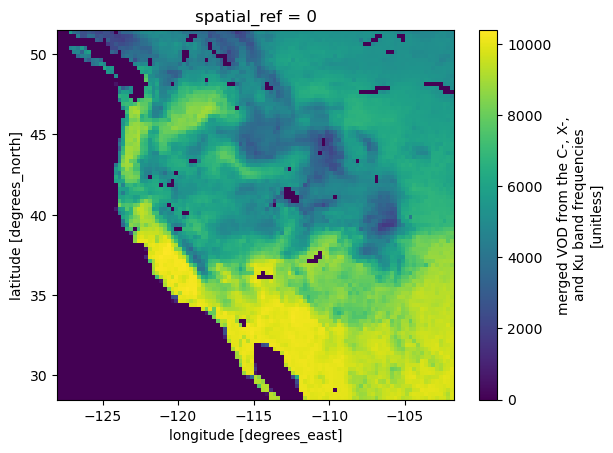

In [7]:
vodca_clip_nobs.VODCA_CXKu.plot()

In [8]:
ads = xr.open_zarr("../../ForestLST/data_working/ads_damage.zarr/").__xarray_dataarray_variable__
ads = ads.sum(dim="var").compute()
ads = ads.transpose("time", "y", "x")
ads

<xarray.DataArray '__xarray_dataarray_variable__' (time: 25, y: 750, x: 600)> Size: 90MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])
Coordinates:
  * time         (time) datetime64[ns] 200B 1999-01-01 2000-01-01 ... 2023-01-01
  * y            (y) float64 6kB 3.179e+06 3.176e+06 ... 9.351e+05 9.321e+05
  * x            (x) float64 5kB -2.361e+06 -2.358e+06 ... -5.673e+05 -5.643e+05
    spatial_ref  int64 8B 0

In [60]:
ads_proj = ads.rio.reproject(dst_crs=vodca_clip.rio.crs, transform=vodca_clip.rio.transform(), resampling="average").rio.clip_box(*vodca_clip.rio.bounds())

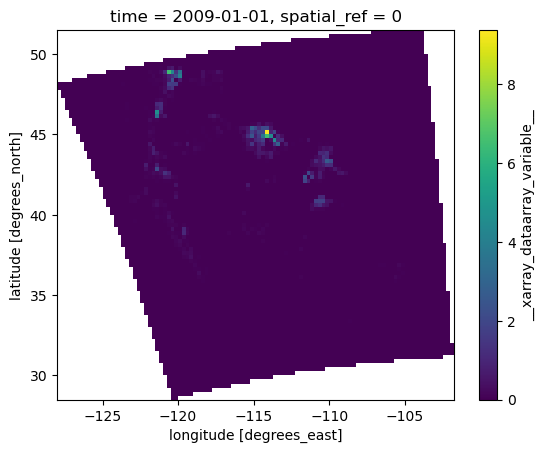

In [61]:
ads_proj.isel(time=10).plot()

In [63]:
assert (ads_proj.x == vodca_clip.x).all()
assert (ads_proj.y == vodca_clip.y).all()

In [65]:
def find_peaks_driver(ts: np.array, max_size:int=5, **kwargs):
    peaks, properties = find_peaks(ts, **kwargs)
    
    if peaks.shape[0] < max_size:
        peaks = np.pad(peaks, (0, max_size - peaks.shape[0]), mode="constant", constant_values=-1)
    else:
        peaks = peaks[:max_size]

    return peaks

In [66]:
ads_peaks = xr.apply_ufunc(
    find_peaks_driver,
    ads_proj,
    input_core_dims=[["time"]],
    output_core_dims=[["peak_idx"]],
    vectorize=True,
    kwargs=dict(height=5, distance=5, prominence=5)
)

In [67]:
# Collect tuples of where peak ADS mortality was observed
peak_tups = []
for y_idx, x_idx, peak_idx in zip(*np.where(ads_peaks > -1)):
    year = ads_proj.time.isel(time=ads_peaks.isel(y=y_idx, x=x_idx, peak_idx=peak_idx)).data
    year = year.astype('datetime64[D]')
    peak_tups.append((
        ads_peaks.y.isel(y=y_idx).data,
        ads_peaks.x.isel(x=x_idx).data,
        year
    ))    

peak_df = pd.DataFrame(peak_tups, columns=["x", "y", "event_start"])

In [104]:
def get_ts(row_idx: int, lookback_yrs:float = 5):
    t_start = peak_df["event_start"].iloc[row_idx]
    return vodca_clip.VODCA_CXKu.sel(
        y=peak_df["y"].iloc[row_idx],
        x=peak_df["x"].iloc[row_idx],
        method="nearest"
    ).sel(
        time=slice(t_start - np.timedelta64(lookback_yrs * 365, "D"), t_start),
    ).compute()

In [95]:
def spectral_power(ts: np.array, **spectrogram_args):
    #replace nan with the mean
    ts_ = np.nan_to_num(ts, nan=np.nanmean(ts))
    ts_ = detrend(ts_)
    f, t, Sxx = spectrogram(ts_, 1, scaling="spectrum", **spectrogram_args)
    t_asdate = ts.time.isel(time=t.astype(np.int32))
    return f, t_asdate, Sxx
    

In [83]:
def plot_spectrogram(f, t, Sxx):
    plt.pcolormesh(t, f, Sxx)
    plt.ylabel('Frequency [1/Day]')
    plt.xlabel('Time')

In [101]:
def power_trend(row_idx: int, max_freq: float, lookback_yrs:int=5, **spectrogram_args):
    row = peak_df.iloc[row_idx]
    ts = get_ts(row_idx, lookback_yrs=lookback_yrs)
    if np.isnan(ts).all():
        return np.nan

    f, t, Sxx = spectral_power(ts, **spectrogram_args)

    Sxx_filter = Sxx[f < max_freq, :].sum(axis=0)

    Sxx_trend  = np.polyfit(np.linspace(0, lookback_yrs, num=Sxx_filter.shape[0]), Sxx_filter, 1)[0]

    return Sxx_trend

In [102]:
power_trend(0, max_freq=0.01, nperseg=512, noverlap=256)

2009-01-01


0.0005654853361879226

In [ ]:
power_trends = []
for i in tqdm(range(peak_df.shape[0])):
    power_trends.append(power_trend(i, 0.01, nperseg=512, noverlap=256))

In [108]:
scipy.stats.wilcoxon(power_trends, alternative="less", nan_policy="omit")

WilcoxonResult(statistic=2771.0, pvalue=0.12577687670915916)

(array([34.,  0.,  3.,  0.,  1., 27., 18.,  9.,  0., 20.]),
 array([-7.44727028e-04, -6.10209577e-04, -4.75692127e-04, -3.41174676e-04,
        -2.06657226e-04, -7.21397753e-05,  6.23776753e-05,  1.96895126e-04,
         3.31412576e-04,  4.65930027e-04,  6.00447477e-04]),
 <BarContainer object of 10 artists>)

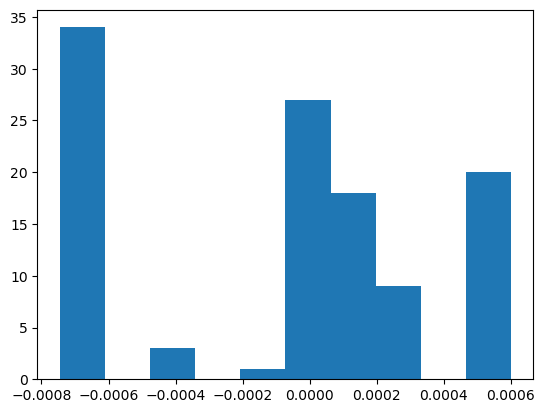

In [107]:
plt.hist(power_trends)

In [65]:
(power_change_df["pre"] < 0).value_counts()

pre
False    586
True     420
Name: count, dtype: int64

In [66]:
(power_change_df["post"] < 0).value_counts()

post
True     674
False    332
Name: count, dtype: int64

In [67]:
(power_change_df["post"] < power_change_df["pre"]).value_counts()

True     603
False    403
Name: count, dtype: int64

In [73]:
pd.crosstab(power_change_df["pre"] < 0, power_change_df["post"] < 0)

post,False,True
pre,,
False,237,349
True,95,325


In [68]:
event_start = np.datetime64("2010-01-01")
np.where(t_asdate > event_start)[0][0]

18

In [69]:
f, t, Sxx = spectral_power(
    get_ts(mort_filter["lat"].iloc[5], mort_filter["long"].iloc[5]),
    nperseg=512, noverlap=512 // 2
)

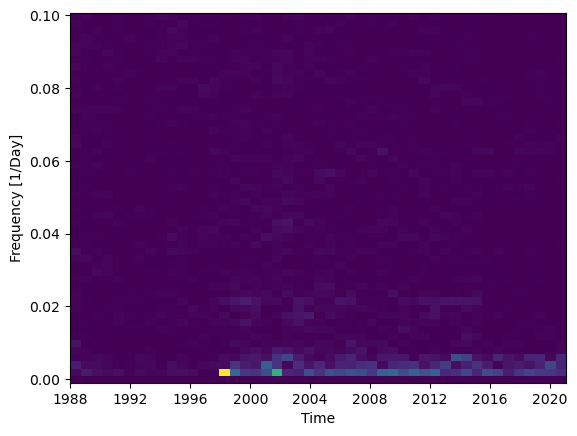

In [70]:
plot_spectrogram(f[f < 0.1], t, Sxx[f < 0.1, :])